In [12]:
import numpy as np
import matplotlib.pyplot as plt

def custom_least_squares_line(x, y):
    # Returns slope m and intercept b for y = mx + b using the closed-form least-squares formulas

    n = len(x)                                        # Number of data points
    x_mean = np.mean(x)                               # Mean of the x values
    y_mean = np.mean(y)                               # Mean of the y values

    numerator = np.sum((x - x_mean) * (y - y_mean))   # Numerator in the slope formula
    denominator = np.sum((x - x_mean) ** 2)           # Denominator in the slope formula

    m = numerator / denominator                       # Best-fit slope
    b = y_mean - m * x_mean                           # Best-fit intercept

    return m, b

def numpy_least_squares_line(x, y):
    # Returns slope m and intercept b for y = mx + b using NumPy's least-squares solver

    A = np.vstack([x, np.ones(len(x))]).T             # Build the design matrix [x  1]
    m, b = np.linalg.lstsq(A, y, rcond=None)[0]       # Solve Ax ≈ y for slope and intercept

    return m, b

def mse(y, yhat):
    # Compute mean squared error between actual and predicted values
    return np.mean((y - yhat) ** 2)

def r2_score(y, yhat):
    # Compute R^2 to measure goodness of fit

    ss_res = np.sum((y - yhat) ** 2)                  # Residual sum of squares
    ss_tot = np.sum((y - np.mean(y)) ** 2)            # Total sum of squares

    return 1 - ss_res / ss_tot                        # R^2 value

def print_residual_summary(x, y, yhat, label):
    # Print all residuals and identify the points with the largest and smallest residual errors

    residuals = y - yhat                              # Residual = actual - predicted
    abs_residuals = np.abs(residuals)                 # Absolute size of each residual

    max_index = np.argmax(abs_residuals)              # Index of largest residual magnitude
    min_index = np.argmin(abs_residuals)              # Index of smallest residual magnitude

    print(f"\n{label} Residuals")
    print("Index    x         y         yhat      residual")

    for i in range(len(x)):
        print(f"{i:3d}   {x[i]:7.4f}   {y[i]:7.4f}   {yhat[i]:7.4f}   {residuals[i]:9.6f}")

    print(f"\nLargest residual error occurs at index {max_index}:")
    print(f"x = {x[max_index]:.4f}, y = {y[max_index]:.4f}, yhat = {yhat[max_index]:.4f}, residual = {residuals[max_index]:.6f}")

    print(f"\nSmallest residual error occurs at index {min_index}:")
    print(f"x = {x[min_index]:.4f}, y = {y[min_index]:.4f}, yhat = {yhat[min_index]:.4f}, residual = {residuals[min_index]:.6f}")

    return residuals

Part 1: Random X and Y Vectors
Custom least squares:
Slope = -0.167856, Intercept = 6.048762
MSE = 8.638800, R^2 = 0.026927

NumPy least squares:
Slope = -0.167856, Intercept = 6.048762
MSE = 8.638800, R^2 = 0.026927

Difference between custom and NumPy results:
Slope difference = 0.000000000000
Intercept difference = 0.000000000000


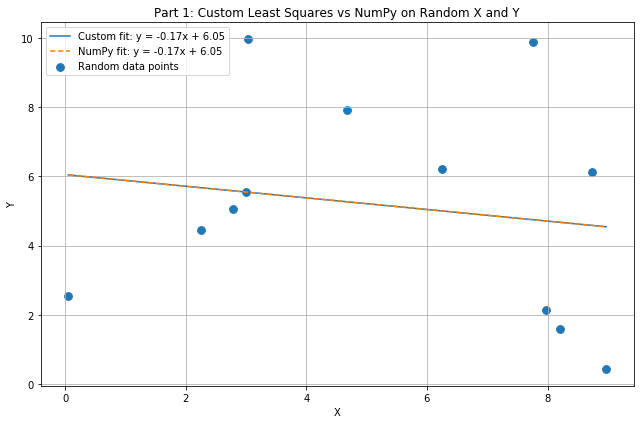

In [13]:
# Part 1: Test the least-Squares methods using random vectors

rng = np.random.default_rng(7)                        # Random number generator for repeatable results

X1 = rng.uniform(0, 10, 12)                           # Generate random x values
Y1 = rng.uniform(0, 10, 12)                           # Generate random y values

X1 = np.sort(X1)                                      # Sort the x vector as required

m1_custom, b1_custom = custom_least_squares_line(X1, Y1)   # Fit line using custom method
m1_numpy, b1_numpy = numpy_least_squares_line(X1, Y1)      # Fit line using NumPy

Yhat1_custom = m1_custom * X1 + b1_custom             # Predicted y values from custom fit
Yhat1_numpy = m1_numpy * X1 + b1_numpy                # Predicted y values from NumPy fit

print("Part 1: Random X and Y Vectors")
print("Custom least squares:")
print(f"Slope = {m1_custom:.6f}, Intercept = {b1_custom:.6f}")
print(f"MSE = {mse(Y1, Yhat1_custom):.6f}, R^2 = {r2_score(Y1, Yhat1_custom):.6f}")

print("\nNumPy least squares:")
print(f"Slope = {m1_numpy:.6f}, Intercept = {b1_numpy:.6f}")
print(f"MSE = {mse(Y1, Yhat1_numpy):.6f}, R^2 = {r2_score(Y1, Yhat1_numpy):.6f}")

print("\nDifference between custom and NumPy results:")
print(f"Slope difference = {abs(m1_custom - m1_numpy):.12f}")
print(f"Intercept difference = {abs(b1_custom - b1_numpy):.12f}")

fig, ax = plt.subplots(figsize=(9, 6))                # Create figure and axes for Part 1
ax.scatter(X1, Y1, s=60, label="Random data points")  # Plot random points
ax.plot(X1, Yhat1_custom, label=f"Custom fit: y = {m1_custom:.2f}x + {b1_custom:.2f}")   # Plot custom fit
ax.plot(X1, Yhat1_numpy, '--', label=f"NumPy fit: y = {m1_numpy:.2f}x + {b1_numpy:.2f}") # Plot NumPy fit
ax.set_title("Part 1: Custom Least Squares vs NumPy on Random X and Y")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.legend()
ax.grid(True)
plt.tight_layout()                                    # Adjust spacing so labels fit nicely
plt.show()                                            # Display the plot
plt.close(fig)                                        # Close the figure so it does not echo later

Part 2: Linear Function with Random Error
True underlying line:
y = 2.400000x + -0.350000

Custom least squares result:
Slope = 2.327690, Intercept = -0.303553
MSE = 0.356979, R^2 = 0.563340

NumPy least squares result:
Slope = 2.327690, Intercept = -0.303553
MSE = 0.356979, R^2 = 0.563340

Difference between custom and NumPy results:
Slope difference = 0.000000000000
Intercept difference = 0.000000000000

Difference between recovered line and true line:
Custom slope error = 0.072310
Custom intercept error = 0.046447
NumPy slope error = 0.072310
NumPy intercept error = 0.046447

Custom Fit Residuals
Index    x         y         yhat      residual
  0    0.0000   -1.1951   -0.3036   -0.891522
  1    0.0100   -1.2709   -0.2803   -0.990672
  2    0.0200   -1.2059   -0.2570   -0.948918
  3    0.0300    0.2917   -0.2337    0.525441
  4    0.0400   -0.1085   -0.2104    0.101905
  5    0.0500   -0.4225   -0.1872   -0.235295
  6    0.0600    0.7219   -0.1639    0.885797
  7    0.0700    0.3703

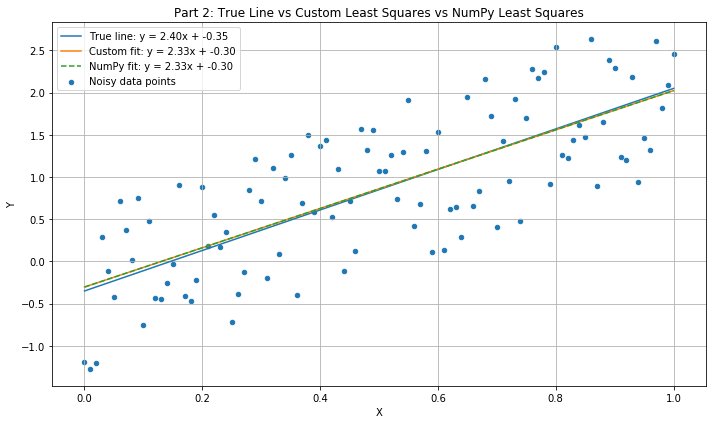

In [14]:
# Part 2: Choosing my own linear function with random error

m_true = 2.4                                          # Chosen true slope
b_true = -0.35                                        # Chosen true intercept

X2 = np.arange(0, 1.01, 0.01)                         # Create x values from 0 to 1 in steps of 0.01

noise_sign = rng.choice([-1, 1], size=X2.shape)       # Randomly choose plus or minus signs
noise_mag = rng.uniform(0, 1, size=X2.shape)          # Random error magnitudes between 0 and 1
noise = noise_sign * noise_mag                        # Final signed random noise

Y2 = m_true * X2 + b_true + noise                     # Create y = mx + b +/- random_number(0,1)

m2_custom, b2_custom = custom_least_squares_line(X2, Y2)   # Fit line using custom method
m2_numpy, b2_numpy = numpy_least_squares_line(X2, Y2)      # Fit line using NumPy

Yhat2_custom = m2_custom * X2 + b2_custom             # Predicted y values from custom fit
Yhat2_numpy = m2_numpy * X2 + b2_numpy                # Predicted y values from NumPy fit
Ytrue = m_true * X2 + b_true                          # Exact underlying line without noise

print("Part 2: Linear Function with Random Error")
print("True underlying line:")
print(f"y = {m_true:.6f}x + {b_true:.6f}")

print("\nCustom least squares result:")
print(f"Slope = {m2_custom:.6f}, Intercept = {b2_custom:.6f}")
print(f"MSE = {mse(Y2, Yhat2_custom):.6f}, R^2 = {r2_score(Y2, Yhat2_custom):.6f}")

print("\nNumPy least squares result:")
print(f"Slope = {m2_numpy:.6f}, Intercept = {b2_numpy:.6f}")
print(f"MSE = {mse(Y2, Yhat2_numpy):.6f}, R^2 = {r2_score(Y2, Yhat2_numpy):.6f}")

print("\nDifference between custom and NumPy results:")
print(f"Slope difference = {abs(m2_custom - m2_numpy):.12f}")
print(f"Intercept difference = {abs(b2_custom - b2_numpy):.12f}")

print("\nDifference between recovered line and true line:")
print(f"Custom slope error = {abs(m2_custom - m_true):.6f}")
print(f"Custom intercept error = {abs(b2_custom - b_true):.6f}")
print(f"NumPy slope error = {abs(m2_numpy - m_true):.6f}")
print(f"NumPy intercept error = {abs(b2_numpy - b_true):.6f}")

residuals_custom = print_residual_summary(X2, Y2, Yhat2_custom, "Custom Fit")   # Print custom residuals
residuals_numpy = print_residual_summary(X2, Y2, Yhat2_numpy, "NumPy Fit")      # Print NumPy residuals

fig, ax = plt.subplots(figsize=(10, 6))               # Create figure and axes for Part 2
ax.scatter(X2, Y2, s=20, label="Noisy data points")   # Plot noisy data
ax.plot(X2, Ytrue, label=f"True line: y = {m_true:.2f}x + {b_true:.2f}")         # Plot original line
ax.plot(X2, Yhat2_custom, label=f"Custom fit: y = {m2_custom:.2f}x + {b2_custom:.2f}")  # Plot custom fit
ax.plot(X2, Yhat2_numpy, '--', label=f"NumPy fit: y = {m2_numpy:.2f}x + {b2_numpy:.2f}")# Plot NumPy fit
ax.set_title("Part 2: True Line vs Custom Least Squares vs NumPy Least Squares")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.legend()
ax.grid(True)
plt.tight_layout()                                    # Adjust spacing
plt.show()                                            # Display the plot
plt.close(fig)                                        # Close the figure




In [15]:
# Final comparison summary

print("Final Comparison Summary")

print("\nOn random X and Y vectors:")
print("The custom least-squares method and NumPy should give essentially the same slope and intercept.")
print("That shows the custom implementation is working correctly.")

print("\nOn generated linear data with noise:")
print("Both methods should recover a line close to the original equation.")
print("The recovered line will not be exact because random error was added to every point.")
print("Residuals measure how far each actual point is from the predicted line.")
print("The largest residual shows the point fit worst by the line.")
print("The smallest residual shows the point fit best by the line.")

print("\nConclusion:")
print("The custom least-squares method matches the built-in NumPy least-squares method very closely.")
print("This confirms that the custom formula-based implementation is correct.")

Final Comparison Summary

On random X and Y vectors:
The custom least-squares method and NumPy should give essentially the same slope and intercept.
That shows the custom implementation is working correctly.

On generated linear data with noise:
Both methods should recover a line close to the original equation.
The recovered line will not be exact because random error was added to every point.
Residuals measure how far each actual point is from the predicted line.
The largest residual shows the point fit worst by the line.
The smallest residual shows the point fit best by the line.

Conclusion:
The custom least-squares method matches the built-in NumPy least-squares method very closely.
This confirms that the custom formula-based implementation is correct.
